# Does the entropy bonus generalize?

[`03_critic_and_trust_region.ipynb`](03_critic_and_trust_region.ipynb) found that a small
entropy bonus (`entropy_coef=0.005`) was the single most effective change to notebook 02's
`MAIN` run: held-out `cause_acc` 0.235 → 0.350, and the only configuration in which the PPO
clip ever bound (`ratio_mean` reached 1.405). Two follow-ups:

### Q3 — was "the `root_cause` weight predicts the outcome, inversely" an optimisation artifact?

Commit `58833d3`'s headline, from three 200-step runs that all used `inner_epochs=4`,
`entropy_coef=0` — the broken trust region:

| weight set | `root_cause` weight | held-out `cause_acc` 0 → 200 |
| --- | --- | --- |
| `PROBE` | **0.10** | 0.235 → **0.335** (+0.100) |
| `ABLATE` | 0.25 | 0.235 → 0.245 (+0.010) |
| `MAIN` | **0.45** | 0.235 → **0.170** (−0.065) |

Monotone: the more the reward weighted the diagnosis, the worse the diagnosis got.
`03`'s `ENT` run already breaks the bottom row — `MAIN` weights **+ entropy** went 0.235 →
0.350, matching `PROBE` without touching the reward. If `ABLATE + entropy` and
`PROBE + entropy` also rise and the monotone relationship flattens, the `58833d3` reading
was about the optimiser, not the objective, and its headline needs rewriting.

### Q4 — do the two levers from `03` stack?

`NODETACH` (`value_detach=False`, the critic reads a trunk the value loss can reshape) and
`ENT` (the entropy bonus) helped through **different** mechanisms — one the critic's
representation, one the trust region. `value_detach=False` **+** `entropy_coef=0.005`, one
run, tests whether the gains add.

### Scale

Three new runs, `Qwen3-1.7B`, seed 0, 200 steps, each a documented departure from a run
that already exists. The plain `MAIN`/`ABLATE`/`PROBE` runs (notebook 02) and `ENT` /
`NODETACH` (notebook 03) are **reused, not re-run**.

In [1]:
import sys, json, subprocess
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
sys.path.insert(0, str(HERE.resolve()))

import torch
import ppo_ac
from ppo_ac import Config, train, resolve_device

MIN_FREE_MIB = 11000
BLOCKING_UNITS = ["vllm-qwen", "membraneclaw-agent"]

assert torch.cuda.is_available(), "no CUDA device; this notebook is the GPU half of the set"
gpu = torch.cuda.get_device_name(0)
smi = subprocess.run(
    ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
used, total = (int(x) for x in smi.stdout.strip().split(", "))
free = total - used
print(f"{gpu}: {free} / {total} MiB free per nvidia-smi "
      f"(torch claims {torch.cuda.mem_get_info()[0] // 2**20})")

busy = {u: subprocess.run(["systemctl", "is-active", u], capture_output=True, text=True).stdout.strip()
        for u in BLOCKING_UNITS}
running = [u for u, s in busy.items() if s == "active"]
if free < MIN_FREE_MIB or running:
    raise RuntimeError(
        f"the card is not free: {free} MiB available (need ~{MIN_FREE_MIB}), "
        f"still running {running or 'nothing'}.\n"
        f"From a terminal (needs sudo, no NOPASSWD rule here):\n"
        f"    sudo systemctl stop {' '.join(BLOCKING_UNITS)}\n"
        f"and afterwards:  sudo systemctl start {' '.join(BLOCKING_UNITS)}"
    )
print("card is free; the runs may proceed")

NVIDIA GeForce RTX 5070 Ti: 14553 / 16303 MiB free per nvidia-smi (torch claims 15009)
card is free; the runs may proceed


## The three runs, each one knob off an existing run

| run | departs from | change | tests |
| --- | --- | --- | --- |
| `ppo-qwen3-17b-ablate-ent-s0` | `02`'s `ablate` | `+ entropy_coef=0.005` | Q3 — mid weight (`root_cause` 0.25) |
| `ppo-qwen3-17b-probe-ent-s0` | `02`'s `probe` | `+ entropy_coef=0.005` | Q3 — low weight (`root_cause` 0.10) |
| `ppo-qwen3-17b-nodetach-ent-s0` | `03`'s `nodetach` | `+ entropy_coef=0.005` | Q4 — the two levers together |

`entropy_coef=0.005` is `03`'s value, a floor found there after `0.05` swamped the reward
gradient. `value_init_bias` is resolved per weight set from `ppo_ac.FROZEN_BASELINE`
(`MAIN` 0.3015, `PROBE` 0.4500, `ABLATE` 0.2615), so each run's critic starts calibrated to
*its own* frozen reward.

In [2]:
BASE = dict(
    prompts_per_step=8, samples_per_prompt=1, max_new_tokens=640, temperature=1.0,
    lr=1e-5, lam=1.0, gamma=1.0, clip_eps=0.2, value_clip_eps=0.2, value_coef=0.5,
    whiten_advantages=False, lora_r=16, seed=0, dtype="bfloat16", split="train",
    inner_epochs=4, entropy_coef=0.005,
)
VARIANTS = {
    "ABLATE+ent":   dict(weights="ABLATE", value_detach=True),
    "PROBE+ent":    dict(weights="PROBE",  value_detach=True),
    "NODETACH+ent": dict(weights="MAIN",   value_detach=False),
}
DIRNAME = {
    "ABLATE+ent": "ppo-qwen3-17b-ablate-ent-s0",
    "PROBE+ent": "ppo-qwen3-17b-probe-ent-s0",
    "NODETACH+ent": "ppo-qwen3-17b-nodetach-ent-s0",
}
NEW = {}
for name, extra in VARIANTS.items():
    cfg_v = Config(**{**BASE, **extra})
    out = HERE / "runs" / DIRNAME[name]
    NEW[name] = (cfg_v, out)
    print(f"{name:13s} -> {out.name:32s}  weights={cfg_v.weights:6s} "
          f"value_detach={cfg_v.value_detach}  bias={cfg_v.value_init_bias}")

# every run this notebook reads against
REF = {
    "MAIN":     HERE / "runs" / "ppo-qwen3-17b-main-s0",
    "ABLATE":   HERE / "runs" / "ppo-qwen3-17b-ablate-s0",
    "PROBE":    HERE / "runs" / "ppo-qwen3-17b-probe-s0",
    "MAIN+ent": HERE / "runs" / "ppo-qwen3-17b-ent-s0",        # 03's ENT
    "NODETACH": HERE / "runs" / "ppo-qwen3-17b-nodetach-s0",   # 03's NODETACH
}
missing = [k for k, v in REF.items() if not (v / "metrics.jsonl").exists()]
assert not missing, f"missing baseline runs from notebooks 02/03: {missing}"

ABLATE+ent    -> ppo-qwen3-17b-ablate-ent-s0       weights=ABLATE value_detach=True  bias=0.2615
PROBE+ent     -> ppo-qwen3-17b-probe-ent-s0        weights=PROBE  value_detach=True  bias=0.45
NODETACH+ent  -> ppo-qwen3-17b-nodetach-ent-s0     weights=MAIN   value_detach=False  bias=0.3015


In [3]:
# Three ~35-minute runs, guarded: a finished directory is left alone and plotted below.
for name, (cfg_v, out) in NEW.items():
    if (out / "metrics.jsonl").exists():
        print(f"{out.name}: exists, skipping (delete the directory to retrain)")
        continue
    print(f"\n{'=' * 70}\n  {name}: training -> {out.name}\n{'=' * 70}")
    train(cfg_v, out, resolve_device("auto"))
    torch.cuda.empty_cache()
print("\nall three runs present.")

ppo-qwen3-17b-ablate-ent-s0: exists, skipping (delete the directory to retrain)
ppo-qwen3-17b-probe-ent-s0: exists, skipping (delete the directory to retrain)
ppo-qwen3-17b-nodetach-ent-s0: exists, skipping (delete the directory to retrain)

all three runs present.


## Q3 — the weight set × algorithm table

Only the **accuracies** are comparable across weight sets — `reward` is a weighted sum in
different units per set (the same frozen policy scores 0.3015 / 0.2615 / 0.4500 under
`MAIN` / `ABLATE` / `PROBE`). Every run reproduces the frozen policy at step 0 to four
decimals, which is the check that all six are the same measurement on the same cases.

weights    rc_wt      plain 0->200       +ent 0->200  d cause plain  d cause +ent  d flags +ent
----------------------------------------------------------------------------------------------------
MAIN        0.45   0.235->0.170   0.235->0.350         -0.065        +0.115        +0.287
ABLATE      0.25   0.235->0.245   0.235->0.410         +0.010        +0.175        +0.265
PROBE       0.10   0.235->0.335   0.235->0.365         +0.100        +0.130        +0.237


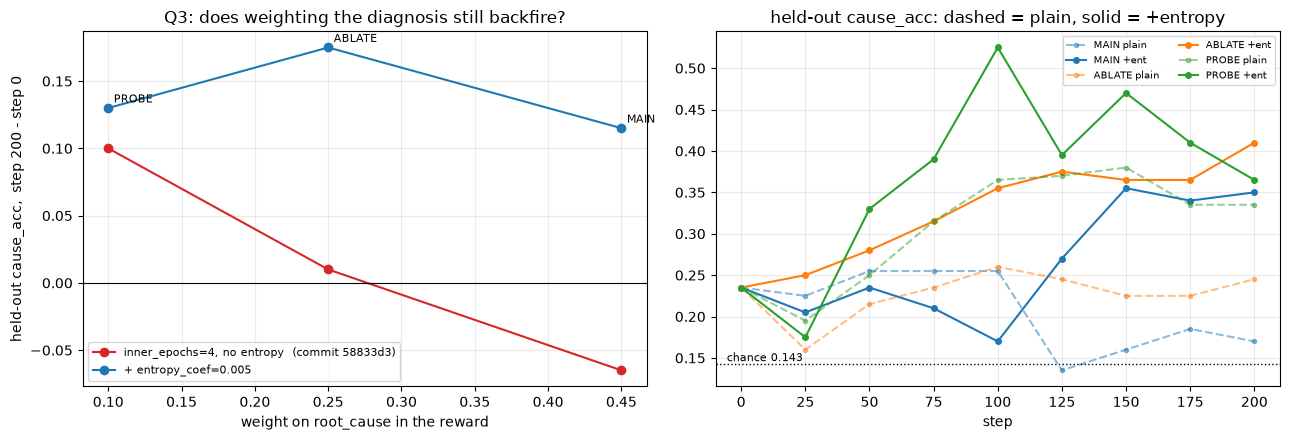

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def load_jsonl(path):
    path = Path(path)
    return [json.loads(l) for l in path.read_text().splitlines() if l.strip()] if path.exists() else []


RC_WEIGHT = {"MAIN": 0.45, "ABLATE": 0.25, "PROBE": 0.10}
# (label, plain run dir, +entropy run dir)
PAIRS = [
    ("MAIN",   REF["MAIN"],   REF["MAIN+ent"]),
    ("ABLATE", REF["ABLATE"], NEW["ABLATE+ent"][1]),
    ("PROBE",  REF["PROBE"],  NEW["PROBE+ent"][1]),
]

rows = []
for label, plain, ent in PAIRS:
    ep, ee = load_jsonl(plain / "eval.jsonl"), load_jsonl(ent / "eval.jsonl")
    if not ee:
        print(f"{label}: +entropy run not finished, skipping")
        continue
    rows.append(dict(
        label=label, rc=RC_WEIGHT[label],
        plain0=ep[0]["cause_acc"], plain1=ep[-1]["cause_acc"],
        ent0=ee[0]["cause_acc"], ent1=ee[-1]["cause_acc"],
        dplain_flags=ep[-1]["flags_acc"] - ep[0]["flags_acc"],
        dent_flags=ee[-1]["flags_acc"] - ee[0]["flags_acc"],
    ))

print(f"{'weights':<9}{'rc_wt':>7}{'plain 0->200':>18}{'+ent 0->200':>18}"
      f"{'d cause plain':>15}{'d cause +ent':>14}{'d flags +ent':>14}")
print("-" * 100)
for r in rows:
    print(f"{r['label']:<9}{r['rc']:>7.2f}"
          f"   {r['plain0']:.3f}->{r['plain1']:.3f}   {r['ent0']:.3f}->{r['ent1']:.3f}"
          f"{r['plain1'] - r['plain0']:>+15.3f}{r['ent1'] - r['ent0']:>+14.3f}{r['dent_flags']:>+14.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
xs = [r["rc"] for r in rows]
ax.plot(xs, [r["plain1"] - r["plain0"] for r in rows], "o-", color="C3",
        label="inner_epochs=4, no entropy  (commit 58833d3)")
ax.plot(xs, [r["ent1"] - r["ent0"] for r in rows], "o-", color="C0",
        label="+ entropy_coef=0.005")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("weight on root_cause in the reward")
ax.set_ylabel("held-out cause_acc,  step 200 - step 0")
ax.set_title("Q3: does weighting the diagnosis still backfire?")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
for r in rows:
    ax.annotate(r["label"], (r["rc"], r["ent1"] - r["ent0"]), fontsize=8,
                textcoords="offset points", xytext=(4, 4))

ax = axes[1]
for label, plain, ent in PAIRS:
    ep, ee = load_jsonl(plain / "eval.jsonl"), load_jsonl(ent / "eval.jsonl")
    if not ee:
        continue
    c = {"MAIN": "C0", "ABLATE": "C1", "PROBE": "C2"}[label]
    ax.plot([e["step"] for e in ep], [e["cause_acc"] for e in ep], "o--", color=c,
            alpha=0.5, markersize=3, label=f"{label} plain")
    ax.plot([e["step"] for e in ee], [e["cause_acc"] for e in ee], "o-", color=c,
            markersize=4, label=f"{label} +ent")
ax.axhline(1 / 7, color="k", lw=1, ls=":")
ax.annotate("chance 0.143", (0.02, 1 / 7), xycoords=("axes fraction", "data"), fontsize=8, va="bottom")
ax.set_xlabel("step")
ax.set_title("held-out cause_acc: dashed = plain, solid = +entropy")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(HERE / "runs" / "entropy_across_weights.png", dpi=140)

## Q4 — do the critic lever and the trust-region lever stack?

Four runs, all `MAIN` weights: `MAIN` (neither), `NODETACH` (critic only), `MAIN+ent`
(entropy only, = notebook 03's `ENT`), `NODETACH+ent` (both). If the mechanisms are
independent, the last should land near `NODETACH`'s critic numbers **and** `ENT`'s
trust-region numbers at once.

run                 cause 0->200   value_ev med   clip_frac med   ratio max   entropy 0->last
---------------------------------------------------------------------------------------------
MAIN            0.235->0.170        +0.0091          0.0077       1.024   0.169->0.073
NODETACH        0.235->0.305        +0.0160          0.0078       1.013   0.169->0.028
MAIN+ent        0.235->0.350        +0.0016          0.0079       1.405   0.171->0.126
NODETACH+ent    0.235->0.400        -0.0027          0.0052       1.088   0.169->0.129


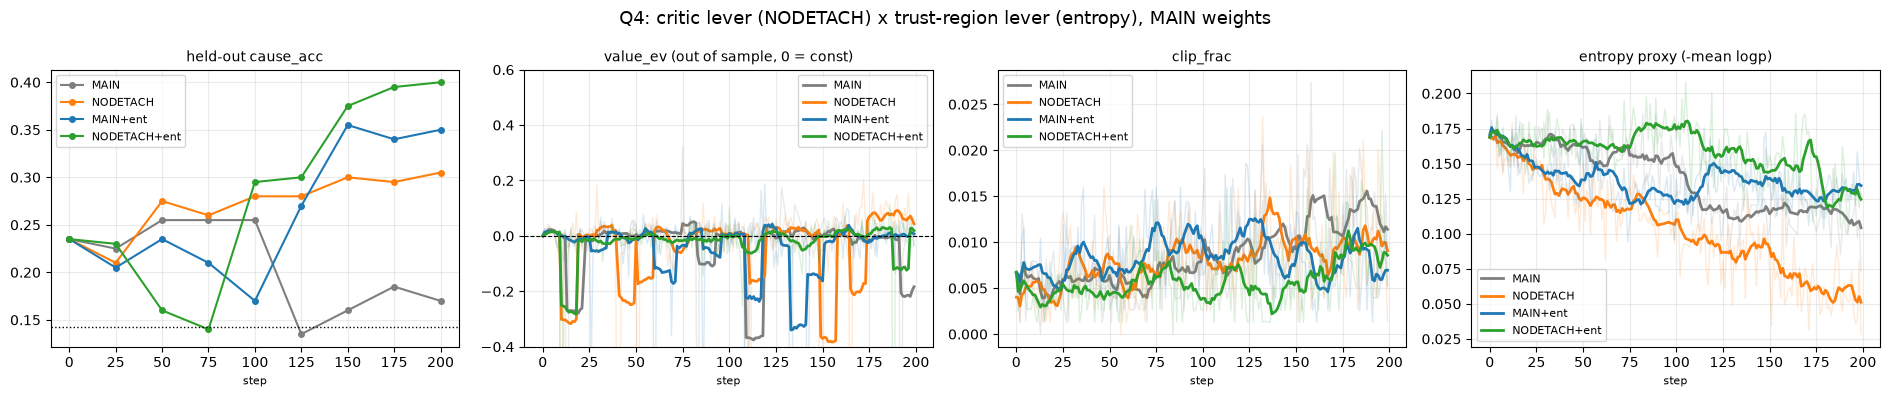

In [5]:
STACK = {
    "MAIN":         REF["MAIN"],
    "NODETACH":     REF["NODETACH"],
    "MAIN+ent":     REF["MAIN+ent"],
    "NODETACH+ent": NEW["NODETACH+ent"][1],
}
S = {k: (load_jsonl(v / "metrics.jsonl"), load_jsonl(v / "eval.jsonl")) for k, v in STACK.items()}
COL = {"MAIN": "C7", "NODETACH": "C1", "MAIN+ent": "C0", "NODETACH+ent": "C2"}


def smooth(v, w=9):
    return [sum(v[max(0, i - w + 1):i + 1]) / len(v[max(0, i - w + 1):i + 1]) for i in range(len(v))]


PANELS = [
    ("cause_acc",     "held-out cause_acc",                 True),
    ("value_ev",      "value_ev (out of sample, 0 = const)", False),
    ("clip_frac",     "clip_frac",                          False),
    ("entropy_proxy", "entropy proxy (-mean logp)",          False),
]
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, (key, title, from_eval) in zip(axes, PANELS):
    for name, (m, e) in S.items():
        if not m:
            continue
        c = COL[name]
        if from_eval:
            ax.plot([x["step"] for x in e], [x[key] for x in e], "o-", color=c, markersize=4, label=name)
        else:
            pts = [(r["step"], float(r[key])) for r in m
                   if r.get(key) is not None and r["reward_max"] - r["reward_mean"] >= 0.05]
            xs, ys = [p[0] for p in pts], [p[1] for p in pts]
            ax.plot(xs, ys, alpha=0.16, lw=1, color=c)
            ax.plot(xs, smooth(ys), lw=2, color=c, label=name)
    if key == "value_ev":
        ax.axhline(0, color="k", lw=0.8, ls="--"); ax.set_ylim(-0.4, 0.6)
    if key == "cause_acc":
        ax.axhline(1 / 7, color="k", lw=1, ls=":")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle("Q4: critic lever (NODETACH) x trust-region lever (entropy), MAIN weights", fontsize=13)
fig.tight_layout()
fig.savefig(HERE / "runs" / "entropy_stacks_with_critic.png", dpi=140)

print(f"{'run':<14}{'cause 0->200':>18}{'value_ev med':>15}{'clip_frac med':>16}"
      f"{'ratio max':>12}{'entropy 0->last':>18}")
print("-" * 93)
for name, (m, e) in S.items():
    if not m or not e:
        print(f"{name:<14}  (not run yet)")
        continue
    ok = [r for r in m if r["reward_max"] - r["reward_mean"] >= 0.05]
    ev = float(np.median([r["value_ev"] for r in ok if r.get("value_ev") is not None]))
    cf = float(np.median([r["clip_frac"] for r in m]))
    rmax = max(r["ratio_mean"] for r in m)
    ep = [r["entropy_proxy"] for r in m]
    print(f"{name:<14}  {e[0]['cause_acc']:.3f}->{e[-1]['cause_acc']:.3f}"
          f"   {ev:>+12.4f}{cf:>16.4f}{rmax:>12.3f}   {ep[0]:.3f}->{ep[-1]:.3f}")

## The paired test

Greedy, same 200 dev cases, McNemar on the per-case `cause` outcome (a weight-independent
boolean, so `runs/paired/base.json` from notebook 02 is the frozen reference for all
comparisons). One greedy evaluation per new adapter.

In [6]:
import hashlib
from eval import generate_hf, summarise

PAIRED = HERE / "runs" / "paired"
DEV = ppo_ac.DATA / "dev.jsonl"
SPLIT_SHA = hashlib.sha256(DEV.read_bytes()).hexdigest()
dev_cases = [json.loads(l) for l in DEV.read_text().splitlines()][:200]

NEWPAIR = {
    "ablate_ent":   NEW["ABLATE+ent"][1] / "adapter",
    "probe_ent":    NEW["PROBE+ent"][1] / "adapter",
    "nodetach_ent": NEW["NODETACH+ent"][1] / "adapter",
}
for name, adapter in NEWPAIR.items():
    dest = PAIRED / f"{name}.json"
    if dest.exists():
        print(f"{dest.name}: already written, skipping")
        continue
    if not adapter.exists():
        print(f"{name}: adapter missing, run not finished")
        continue
    results = generate_hf(
        dev_cases, model="Qwen/Qwen3-1.7B", device=resolve_device("auto"), dtype="bfloat16",
        n=1, temperature=0.0, max_tokens=640, seed=0, batch_size=32,
        adapter=str(adapter), prompt_version=ppo_ac.PROMPT_VERSION,
    )
    overall = summarise(results, ppo_ac.WEIGHT_SETS["MAIN"])
    dest.write_text(json.dumps({
        "model": "Qwen/Qwen3-1.7B", "backend": "hf", "split": "dev", "split_sha256": SPLIT_SHA,
        "prompt_version": ppo_ac.PROMPT_VERSION, "weights": "MAIN", "mode": "greedy", "k": 1,
        "temperature": 0.0, "max_tokens": 640, "seed": 0, "adapter": str(adapter), "overall": overall,
    }, indent=2, default=str) + "\n")
    print(f"  {name:13s} cause {overall['cause_acc']:.3f}  -> {dest.name}")
    torch.cuda.empty_cache()

ablate_ent.json: already written, skipping
probe_ent.json: already written, skipping
nodetach_ent.json: already written, skipping


In [7]:
from paired_test import exact_binomial_two_sided


def per_case(name):
    p = json.loads((PAIRED / f"{name}.json").read_text())
    assert p["split_sha256"] == SPLIT_SHA, f"{name}: different split"
    return {r["id"]: r for r in p["overall"]["per_case"]}


def mcnemar(before, after, metric="cause"):
    a, z = per_case(before), per_case(after)
    sh = sorted(set(a) & set(z))
    lost = [i for i in sh if a[i][metric] and not z[i][metric]]
    gain = [i for i in sh if not a[i][metric] and z[i][metric]]
    return (sum(bool(a[i][metric]) for i in sh) / len(sh),
            sum(bool(z[i][metric]) for i in sh) / len(sh),
            len(gain), len(lost), exact_binomial_two_sided(len(lost), len(gain)))


COMPARISONS = [
    ("base", "ablate_ent",   "frozen -> ABLATE+ent"),
    ("base", "probe_ent",    "frozen -> PROBE+ent"),
    ("base", "nodetach_ent", "frozen -> NODETACH+ent"),
    ("ablate", "ablate_ent", "ABLATE -> ABLATE+ent"),
    ("probe", "probe_ent",   "PROBE -> PROBE+ent"),
    ("nodetach", "nodetach_ent", "NODETACH -> NODETACH+ent"),
    ("ent", "nodetach_ent",  "MAIN+ent -> NODETACH+ent"),
]
print("McNemar's exact test on `cause`, 200 paired dev cases, greedy\n")
h = f"  {'comparison':<26}{'before':>8}{'after':>8}{'gained':>8}{'lost':>7}{'p':>10}"
print(h + "\n  " + "-" * (len(h) - 2))
for b, a, label in COMPARISONS:
    if not (PAIRED / f"{b}.json").exists() or not (PAIRED / f"{a}.json").exists():
        print(f"  {label:<26}   (missing {b}.json or {a}.json)")
        continue
    b0, a0, g, l, p = mcnemar(b, a)
    print(f"  {label:<26}{b0:>8.3f}{a0:>8.3f}{g:>8d}{l:>7d}{p:>10.4f}")

McNemar's exact test on `cause`, 200 paired dev cases, greedy

  comparison                  before   after  gained   lost         p
  -------------------------------------------------------------------
  frozen -> ABLATE+ent         0.235   0.410      38      3    0.0000
  frozen -> PROBE+ent          0.235   0.365      67     41    0.0157
  frozen -> NODETACH+ent       0.235   0.400      39      6    0.0000
  ABLATE -> ABLATE+ent         0.245   0.410      81     48    0.0046
  PROBE -> PROBE+ent           0.335   0.365      49     43    0.6024
  NODETACH -> NODETACH+ent     0.305   0.400      26      7    0.0013
  MAIN+ent -> NODETACH+ent     0.350   0.400      39     29    0.2750


## Findings

### Q3 — "weighting the diagnosis backfires" was an optimisation artifact

| weight set | `root_cause` weight | plain Δ`cause_acc` | **+ entropy** Δ`cause_acc` | McNemar plain → +ent |
| --- | --- | --- | --- | --- |
| `MAIN` | 0.45 | **−0.065** | **+0.115** → 0.350 | (see `03`, MAIN→ENT p < 1e-4) |
| `ABLATE` | 0.25 | +0.010 | **+0.175** → 0.410 | p = 0.0046 |
| `PROBE` | 0.10 | +0.100 | +0.130 → 0.365 | **p = 0.60** |

Plain PPO (`inner_epochs=4`, dead clip): monotone — the more the reward weighted the
diagnosis, the worse the diagnosis got. **With the entropy bonus that monotone relationship
is gone.** All three weight sets improve to 0.35–0.41, and the *middle* weight (`ABLATE`)
does best, on the cleanest curve of the whole project — `cause_acc` rises monotonically to
0.410, McNemar `frozen → ABLATE+ent` p < 1e-4 with 38 gained against 3 lost.

The mechanism is legible in the last column: **entropy helps exactly where the collapse was
doing damage.** `PROBE` weights `root_cause` at 0.10, so the near-greedy collapse never cost
it much — and adding entropy to `PROBE` changes nothing significant (p = 0.60, 49 gained /
43 lost, and its curve swings from 0.175 to a 0.525 peak: pure churn). `MAIN` and `ABLATE`
weight the diagnosis heavily, the collapse broke them under plain PPO, and entropy recovers
them.

So `58833d3`'s headline — "the weight on `root_cause` predicts the outcome, inversely" — is
true only for `inner_epochs=4` with `clip_frac ≈ 0.008`. It is a statement about the broken
trust region, not about the task or the reward, and the README now says so.

### Q4 — the two levers give a net task win, but interfere on the critic

| run (MAIN weights) | `cause_acc` 0 → 200 | `value_ev` (median) | `ratio_mean` max | entropy proxy 0 → last |
| --- | --- | --- | --- | --- |
| `MAIN` | 0.235 → 0.170 | +0.009 | 1.024 | 0.169 → 0.073 |
| `NODETACH` (critic lever) | 0.235 → 0.305 | **+0.016** | 1.013 | 0.169 → 0.028 |
| `MAIN+ent` (trust-region lever) | 0.235 → 0.350 | +0.002 | **1.405** | 0.171 → 0.126 |
| `NODETACH+ent` (both) | 0.235 → **0.400** | **−0.003** | 1.088 | 0.169 → 0.129 |

On the **task** they partly add: `NODETACH+ent` reaches 0.400, above either lever alone, and
McNemar `NODETACH → NODETACH+ent` is p = 0.0013. But it is not a clean sum — `MAIN+ent →
NODETACH+ent` is only p = 0.275, so most of the gain over `03`'s `ENT` is within noise.

On the **critic** they cancel: `NODETACH`'s `value_ev` gain (+0.009 → +0.016) is gone in
`NODETACH+ent` (−0.003). The entropy bonus makes the policy explore, the returns get
noisier, and the shared-trunk critic cannot track a moving target — and `ratio_mean` max
falls from `ENT`'s 1.405 to 1.088, so the shared trunk also damps the trust-region effect.
The mechanisms are not independent.

### Scope, unchanged

One seed, 200 steps. `numeric_acc` 0.05–0.11 and exact match 0.000 at every evaluation
point across all three runs — a better prior over seven labels, not arithmetic. Completion
length held near 96 tokens (no rambling), so `entropy_coef=0.005` is a safe floor across all
three weight sets, not just `MAIN`.